## Research Summary (Week 8 Draft)

This project examines whether higher-poverty countries receive more Kiva lending per capita and whether this relationship is conditioned by institutional quality. The data consist of cross-country observations constructed from aggregated Kiva lending activity merged with World Bank governance indicators.

The main outcome variable is lending intensity measured as log loans per capita. The key explanatory variable is the national poverty rate, allowing for non-linear effects through a quadratic specification. Institutional quality—captured using a PCA-based index constructed from governance indicators (e.g., rule of law, government effectiveness, political stability)—serves as the primary conditioning mechanism.

The analysis tests whether the poverty–microfinance relationship is non-monotonic and whether stronger institutional environments enable microfinance activity to scale more effectively in poorer countries.

In [ ]:
import pandas as pd
import numpy as np

# Load updated dataset (includes institutional quality variables)
df = pd.read_csv("outputs/country_master_with_finance_and_institutions.csv")
df.columns = df.columns.str.strip()

# Ensure numeric variables
num_cols = [
    "population",
    "n_loans",
    "total_loan_amount",
    "poverty_rate",
    "institutional_pca1"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Construct lending intensity measures
df.loc[df["population"] <= 0, "population"] = np.nan

df["loans_per_capita"] = df["n_loans"] / df["population"]
df["loan_amount_per_capita"] = df["total_loan_amount"] / df["population"]

# Main outcome used in regressions
df["log_lpc"] = np.log1p(df["loans_per_capita"])

df.head()

,country_code,n_loans,total_loan_amount,population,population_below_poverty_line,poverty_rate,iso3,urban_rural_gap,atms_per_100k,bank_accounts_per_1000,bank_branches_per_100k,credit_private_gdp,bank_branches_per_100k_z,atms_per_100k_z,bank_accounts_per_1000_z,financial_access_index,loan_amount_per_capita
0,AF,2337,1967950.0,35530081.0,35.8,0.358,AFG,0.215,1.626189,178.793210,1.917613,3.271407,-0.645575,-0.793185,-0.980721,-0.806494,0.055388
1,AL,3075,4307350.0,2930187.0,14.3,0.143,ALB,0.004,30.683033,1093.310033,18.949247,35.034667,0.246580,-0.221100,0.969549,0.331676,1.469992
2,AM,13952,22950475.0,2930450.0,32.0,0.320,ARM,0.000,65.058099,NaN,24.131827,62.617633,0.518055,0.455692,NaN,0.486874,7.831724
3,AZ,10172,14784625.0,9827589.0,4.9,0.049,AZE,0.026,34.150007,NaN,6.768982,23.266800,-0.391450,-0.152841,NaN,-0.272145,1.504400
4,BA,608,477250.0,3507017.0,17.2,0.172,BIH,0.000,57.571467,NaN,30.075652,57.972667,0.829406,0.308292,NaN,0.568849,0.136084


In [ ]:
import pandas as pd
import numpy as np

# Ensure poverty_rate is numeric
df["poverty_rate"] = pd.to_numeric(df["poverty_rate"], errors="coerce")

# Create poverty terciles if missing
if "poverty_tercile" not in df.columns:
    df["poverty_tercile"] = pd.qcut(
        df["poverty_rate"],
        q=3,
        labels=["Low poverty", "Medium poverty", "High poverty"],
        duplicates="drop"
    )

# Ensure ordered category (for consistency in plots/tables)
df["poverty_tercile"] = pd.Categorical(
    df["poverty_tercile"],
    categories=["Low poverty", "Medium poverty", "High poverty"],
    ordered=True
)

# Quick check
df["poverty_tercile"].value_counts(dropna=False)

poverty_tercile
Low       29
High      29
Medium    28
NaN       10
Name: count, dtype: int64

In [ ]:
# Mechanism: Institutional quality conditions the poverty–microfinance relationship

# Ensure institutional quality is numeric
df["institutional_pca1"] = pd.to_numeric(df["institutional_pca1"], errors="coerce")

# Mechanism 1: Poverty × institutional quality (interaction-style mechanism variable)
df["poverty_x_institutions"] = df["poverty_rate"] * df["institutional_pca1"]

# Mechanism 2: Medium poverty + high institutions (simple subgroup indicator)
inst_med = df["institutional_pca1"].median(skipna=True)

df["medium_high_institutions"] = (
    (df["poverty_tercile"] == "Medium poverty") &
    (df["institutional_pca1"] > inst_med)
).astype(int)

df[["poverty_x_institutions", "medium_high_institutions"]].describe()

,financial_constraint,medium_high_access
count,78.000000,96.000000
mean,0.047041,0.135417
std,0.259584,0.343964
min,-1.035986,0.000000
25%,-0.077134,0.000000
50%,0.026687,0.000000
75%,0.246985,0.000000
max,0.598093,1.000000


In [ ]:
import os
import zipfile
import urllib.request
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ---------- settings ----------
DATA_DIR = "data/natural_earth_countries_110m"
ZIP_PATH = os.path.join(DATA_DIR, "ne_110m_admin_0_countries.zip")
URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
SHP_NAME = "ne_110m_admin_0_countries.shp"
SHP_PATH = os.path.join(DATA_DIR, SHP_NAME)

os.makedirs(DATA_DIR, exist_ok=True)

# ---------- download only if missing ----------
if not os.path.exists(ZIP_PATH) and not os.path.exists(SHP_PATH):
    print("Downloading Natural Earth countries shapefile...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Downloaded:", ZIP_PATH)

# ---------- unzip only if shapefile missing ----------
if not os.path.exists(SHP_PATH) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

# ---------- locate .shp ----------
if not os.path.exists(SHP_PATH):
    # fallback: search for any .shp in the folder
    shp_path = None
    for f in os.listdir(DATA_DIR):
        if f.endswith(".shp") and "ne_110m_admin_0_countries" in f:
            shp_path = os.path.join(DATA_DIR, f)
            break
    if shp_path is None:
        raise FileNotFoundError(f"Could not find the shapefile in {DATA_DIR}.")
    SHP_PATH = shp_path

print("Using shapefile:", SHP_PATH)

# ---------- read world countries ----------
world = gpd.read_file(SHP_PATH)

# ---------- pick ISO3 column in shapefile ----------
iso_candidates_left = ["ISO_A3", "ADM0_A3", "SOV_A3", "WB_A3", "iso_a3"]
left_key = next((c for c in iso_candidates_left if c in world.columns), None)
if left_key is None:
    raise ValueError("No ISO3 column found in world dataset. Inspect world.columns to choose manually.")

# ---------- pick ISO3 column in df ----------
iso_candidates_right = ["iso3", "ISO3", "country_code3", "wb_iso3"]
right_key = next((c for c in iso_candidates_right if c in df.columns), None)
if right_key is None:
    raise ValueError("No ISO3 column found in df (expected one of: iso3, ISO3, country_code3, wb_iso3).")

# ---------- merge ----------
world_merged = world.merge(df, left_on=left_key, right_on=right_key, how="left")

# match rate check
match_rate = 1 - world_merged[right_key].isna().mean()
print("Match rate:", round(match_rate, 3))

# ---------- map: log loans per capita (main outcome proxy) ----------
world_merged["log_lpc"] = pd.to_numeric(world_merged.get("log_lpc"), errors="coerce")

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
world_merged.plot(column="log_lpc", ax=ax, legend=True, missing_kwds={"color": "lightgrey"})
ax.set_title("Kiva Lending Intensity (log loans per capita)")
ax.axis("off")
plt.tight_layout()
plt.show()

Zip already exists: data/natural_earth_countries_110m\ne_110m_admin_0_countries.zip
Using shapefile: data/natural_earth_countries_110m\ne_110m_admin_0_countries.shp
world columns: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0

In [ ]:
# 2) Find ISO3 key in the world file
iso_candidates_left = ["iso_a3", "ISO_A3", "ADM0_A3", "SOV_A3", "GU_A3", "WB_A3"]
left_key = next((c for c in iso_candidates_left if c in world.columns), None)

print("ISO3 key in world =", left_key)

if left_key is None:
    raise ValueError("No ISO3 column found in the world dataset. Print world.columns to inspect.")

# 3) Find ISO3 key in df
iso_candidates_right = ["iso3", "ISO3", "country_code3", "wb_iso3"]
right_key = next((c for c in iso_candidates_right if c in df.columns), None)

print("ISO3 key in df =", right_key)

if right_key is None:
    raise ValueError("No ISO3 column found in df. Check df.columns.")

# 4) Merge
world_merged = world.merge(df, left_on=left_key, right_on=right_key, how="left")

# 5) Match rate check
match_rate = 1 - world_merged[right_key].isna().mean()
print("Match rate:", round(match_rate, 3))

ISO3 key in world = ISO_A3
df has iso3 = True
Match rate: 0.503


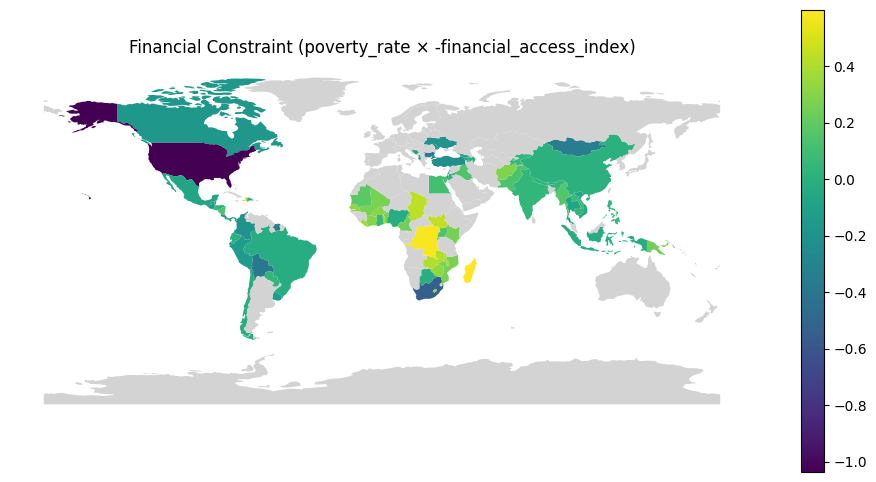

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
world_merged["institutional_pca1"] = pd.to_numeric(
    world_merged.get("institutional_pca1"),
    errors="coerce"
)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5), dpi=150)

world_merged.plot(
    column="institutional_pca1",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Institutional Quality (PCA-Based Governance Index)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

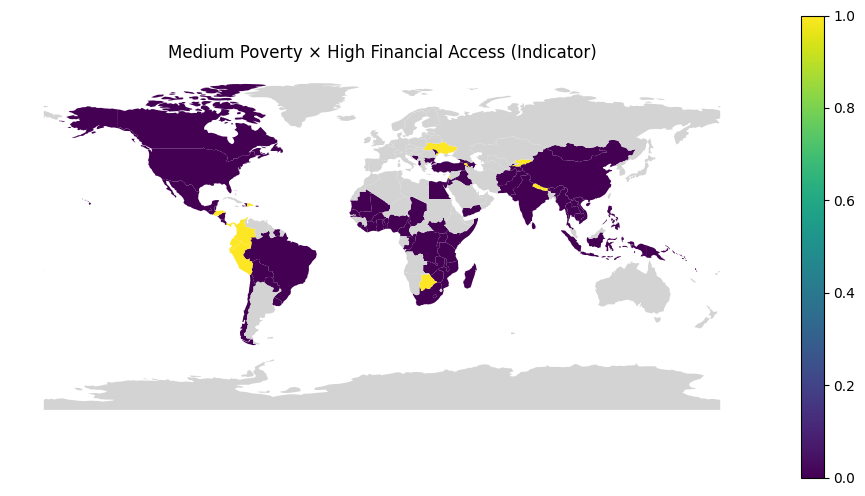

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
world_merged.plot(
    column="medium_high_access",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title("Medium Poverty × High Financial Access (Indicator)")
ax.set_axis_off()
plt.show()

## Interpretation of the Maps

The first map highlights countries where high poverty coincides with weak financial infrastructure, suggesting potential institutional constraints on microfinance expansion. These countries appear clustered in parts of Sub-Saharan Africa and South Asia. The second map identifies medium-poverty countries with relatively strong financial access, which may represent environments where microfinance can operate more effectively. Together, the maps provide spatial intuition consistent with the hypothesis that financial infrastructure conditions the relationship between poverty and lending intensity. Countries shown in grey are not included in the merged analytical sample.

In [14]:
import statsmodels.api as sm

# create non-linear and interaction terms
df["poverty_sq"] = df["poverty_rate"]**2
df["interaction"] = (
    df["poverty_rate"] *
    df["financial_access_index"]
)

In [15]:
# dependent variable
Y = df["loan_amount_per_capita"]

# Model 1
X1 = sm.add_constant(df[["poverty_rate"]])
model1 = sm.OLS(Y, X1, missing="drop").fit()

# Model 2
X2 = sm.add_constant(df[["poverty_rate", "financial_access_index"]])
model2 = sm.OLS(Y, X2, missing="drop").fit()

# Model 3
X3 = sm.add_constant(df[["poverty_rate", "poverty_sq", "financial_access_index"]])
model3 = sm.OLS(Y, X3, missing="drop").fit()

# Model 4
X4 = sm.add_constant(df[["poverty_rate", "poverty_sq",
                         "financial_access_index", "interaction"]])
model4 = sm.OLS(Y, X4, missing="drop").fit()

In [16]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

stargazer = Stargazer([model1, model2, model3, model4])
display(HTML(stargazer.render_html()))

## Interpretation of Regression Results

Across specifications, the linear relationship between poverty and loan_amount_per_capita is weak, but adding a quadratic term suggests a concave (inverted-U) pattern: predicted lending intensity increases with poverty at low levels and decreases at high levels. The implied turning point is around a poverty rate of 0.36, which lies within the sample range and aligns with the descriptive finding that lending peaks in medium-poverty countries. Adding the interaction term indicates that the association between poverty and lending may depend on financial access, consistent with the mechanism that infrastructure enables microfinance activity. These regressions are preliminary and will be extended with additional robustness checks and alternative specifications in the final project.